In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification

In [5]:
X, y = make_classification(n_samples=200, n_features=5, n_informative=5, n_clusters_per_class=1, n_redundant=0)

In [6]:
df = pd.DataFrame(X, columns=['col1', 'col2', 'col3', 'col4', 'col5'])
df['target'] = y
print(df.shape)
df.head()

(200, 6)


,col1,col2,col3,col4,col5,target
0,-1.276377,-0.453095,-0.231764,-2.122120,1.035293,0
1,1.430354,0.409500,1.384992,-0.988688,-0.779892,1
2,-3.345063,0.145239,-1.106558,0.275529,0.908129,0
3,0.219388,1.334196,2.302647,-1.265149,0.824415,1
4,-1.865245,1.817417,0.554032,-0.018938,0.425858,0


In [9]:
#row sampling
def row_sampling(df, percentage):
    return df.sample(int(df.shape[0]*percentage), replace=True)

In [51]:
#feature sampling
def feature_sampling(df, percentage):
    cols = random.sample(df.columns.tolist()[:-1], int((df.shape[1]-1)*percentage))
    new_df = df[cols]
    new_df['target'] = df['target']
    return new_df

In [52]:
#combined sampling (row & column)
def combined_sampling(df, row, column):
    new_df = row_sampling(df, row)
    return feature_sampling(new_df, column)

In [35]:
df1 = row_sampling(df, 0.4)

In [38]:
df1.shape

(80, 6)

In [37]:
df2 = row_sampling(df, 0.4)
df3 = row_sampling(df, 0.4)

In [44]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [34]:
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [43]:
clf1.fit(df1.iloc[:, 0:5], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, 0:5], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, 0:5], df3.iloc[:, -1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

[Text(0.4, 0.9, 'x[0] <= -0.549\ngini = 0.489\nsamples = 80\nvalue = [34, 46]'),
 Text(0.2, 0.7, 'gini = 0.0\nsamples = 26\nvalue = [26, 0]'),
 Text(0.30000000000000004, 0.8, 'True  '),
 Text(0.6, 0.7, 'x[4] <= 1.058\ngini = 0.252\nsamples = 54\nvalue = [8, 46]'),
 Text(0.5, 0.8, '  False'),
 Text(0.4, 0.5, 'x[1] <= 2.92\ngini = 0.042\nsamples = 47\nvalue = [1, 46]'),
 Text(0.2, 0.3, 'gini = 0.0\nsamples = 45\nvalue = [0, 45]'),
 Text(0.6, 0.3, 'x[1] <= 3.157\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.4, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]')]

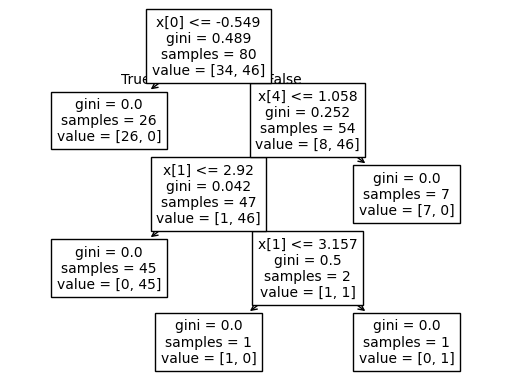

In [45]:
plot_tree(clf1)

[Text(0.4230769230769231, 0.9, 'x[4] <= -0.222\ngini = 0.48\nsamples = 80\nvalue = [48, 32]'),
 Text(0.15384615384615385, 0.7, 'x[2] <= 0.973\ngini = 0.08\nsamples = 24\nvalue = [1, 23]'),
 Text(0.28846153846153844, 0.8, 'True  '),
 Text(0.07692307692307693, 0.5, 'gini = 0.0\nsamples = 18\nvalue = [0, 18]'),
 Text(0.23076923076923078, 0.5, 'x[4] <= -1.229\ngini = 0.278\nsamples = 6\nvalue = [1, 5]'),
 Text(0.15384615384615385, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3076923076923077, 0.3, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.6923076923076923, 0.7, 'x[0] <= 0.075\ngini = 0.27\nsamples = 56\nvalue = [47, 9]'),
 Text(0.5576923076923077, 0.8, '  False'),
 Text(0.5384615384615384, 0.5, 'x[2] <= 3.054\ngini = 0.051\nsamples = 38\nvalue = [37, 1]'),
 Text(0.46153846153846156, 0.3, 'gini = 0.0\nsamples = 37\nvalue = [37, 0]'),
 Text(0.6153846153846154, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8461538461538461, 0.5, 'x[4] <= 1.262\ngini = 0.494\ns

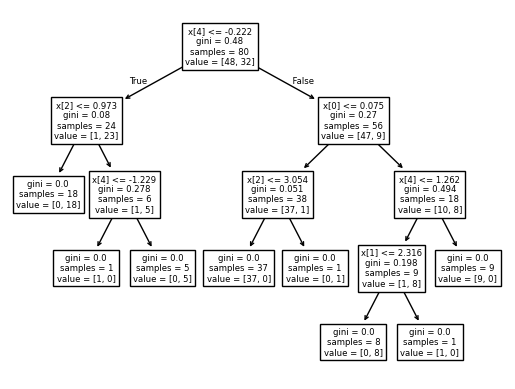

In [46]:
plot_tree(clf2)

[Text(0.5, 0.9166666666666666, 'x[0] <= -0.26\ngini = 0.5\nsamples = 80\nvalue = [41, 39]'),
 Text(0.2, 0.75, 'x[4] <= -0.61\ngini = 0.184\nsamples = 39\nvalue = [35, 4]'),
 Text(0.35, 0.8333333333333333, 'True  '),
 Text(0.1, 0.5833333333333334, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.3, 0.5833333333333334, 'x[2] <= 3.534\ngini = 0.102\nsamples = 37\nvalue = [35, 2]'),
 Text(0.2, 0.4166666666666667, 'x[1] <= 3.048\ngini = 0.054\nsamples = 36\nvalue = [35, 1]'),
 Text(0.1, 0.25, 'gini = 0.0\nsamples = 33\nvalue = [33, 0]'),
 Text(0.3, 0.25, 'x[4] <= 0.636\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.2, 0.08333333333333333, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.4, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.75, 'x[4] <= 1.262\ngini = 0.25\nsamples = 41\nvalue = [6, 35]'),
 Text(0.65, 0.8333333333333333, '  False'),
 Text(0.7, 0.5833333333333334,

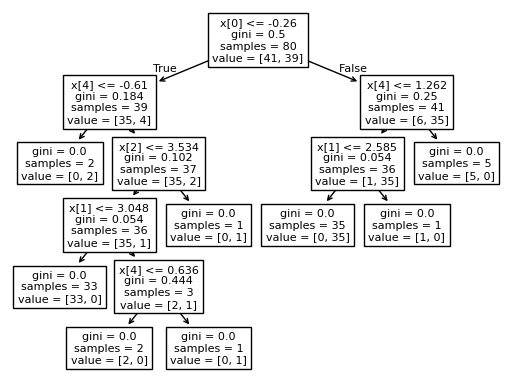

In [47]:
plot_tree(clf3)

In [48]:
clf1.predict(np.array([1.430354, 0.409500, 1.384992, -0.988688, -0.779892]).reshape(1, 5))

C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [49]:
clf2.predict(np.array([1.430354, 0.409500, 1.384992, -0.988688, -0.779892]).reshape(1, 5))

C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [50]:
clf3.predict(np.array([1.430354, 0.409500, 1.384992, -0.988688, -0.779892]).reshape(1, 5))

C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])